# Reto: Segmentación de Empleados para Entender la Deserción
**Autor:** Bernardo Lozano Wise

**Fecha:** 09 de Septiembre, 2025

**Identidad / AI Partner:** WiseX Ex Machina

**Filosofía:** "El hombre proporciona la intuición; la máquina, la verdad estadística. Juntos, alcanzan la sabiduría."

---

### 1. Objetivo de Negocio
El propósito de este análisis es utilizar técnicas de clustering no supervisado para segmentar a los empleados de la organización. El objetivo final es identificar arquetipos de empleados distintos, analizar la tasa de deserción (`Attrition_rate`) dentro de cada segmento y proponer hipótesis accionables que puedan informar futuras estrategias de retención de talento.

### 2. Metodología
Se seguirá un enfoque de ciencia de datos reproducible y defendible, formalizado en el `Framework Analítico para Aprendizaje No Supervisado v2.0`. El proceso incluye:
*   **Análisis Exploratorio de Datos (EDA):** Para formular hipótesis iniciales.
*   **Preprocesamiento Robusto:** Uso de `Pipelines` y `ColumnTransformer` para manejar datos faltantes, escalar variables numéricas y codificar variables categóricas de manera sistemática.
*   **Selección Empírica de Hiperparámetros:** Justificación cuantitativa del número de clústeres (`k`) mediante el análisis del Coeficiente de Silueta.
*   **Interpretación y Perfilado:** Conexión de los resultados matemáticos con insights de negocio a través del perfilado de clústeres y la visualización de datos.

In [2]:
#### Fase 1.1 - Configuración e Importación de Librerías**


# --- 1. CONFIGURACIÓN DEL ENTORNO ---

# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- Scikit-learn for Preprocessing, Modeling, and Metrics ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Utility ---
# Para ignorar advertencias futuras que no son críticas
import warnings
warnings.filterwarnings('ignore')

# --- Global Configurations ---
sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# RANDOM_STATE asegura que los resultados aleatorios (como la inicialización de KMeans) sean los mismos cada vez.
RANDOM_STATE = 42

print("Librerías importadas y configuración global aplicada.")

Librerías importadas y configuración global aplicada.


**Instrucción Crítica para la Evaluación:**

Esta libreta carga los datos directamente desde la plataforma Kaggle utilizando su API oficial para garantizar la reproducibilidad. Para ejecutar el análisis, por favor, siga estos dos pasos iniciales:

1.  **Obtenga su Token API de Kaggle:**
    *   Vaya a su perfil de Kaggle -> "Account" -> Sección "API".
    *   Haga clic en **"Create New API Token"**. Esto descargará un archivo `kaggle.json` a su computadora.

2.  **Ejecute la siguiente celda de código.** Se le solicitará que suba el archivo `kaggle.json` que acaba de descargar. El resto del proceso (descarga, descompresión y carga de datos) es automático.


In [3]:
#### **Fase 1.2 - Carga de Datos desde Kaggle API**

# --- 2. CARGA Y ANÁLISIS INICIAL DE DATOS (DESDE KAGGLE API - Versión Robusta) ---

# 2.1. Configuración de la API de Kaggle
from google.colab import files
import os

print("Por favor, suba su archivo 'kaggle.json'")
uploaded = files.upload()

# Obtener la clave del archivo subido (esto maneja si Colab lo renombra)
try:
    # La clave en el diccionario es el nombre original del archivo
    kaggle_api_key_filename = 'kaggle.json'
    assert kaggle_api_key_filename in uploaded.keys(), "El archivo subido no se llama 'kaggle.json'."

    print(f"\n'{kaggle_api_key_filename}' subido correctamente.")

    # Crear el directorio de configuración si no existe
    if not os.path.exists('/root/.kaggle'):
        os.makedirs('/root/.kaggle')

    # Escribir el contenido del archivo en la ubicación correcta
    with open(f'/root/.kaggle/{kaggle_api_key_filename}', 'wb') as f:
        f.write(uploaded[kaggle_api_key_filename])

    # Establecer los permisos correctos para el archivo de credenciales
    os.chmod(f'/root/.kaggle/{kaggle_api_key_filename}', 600)

    # 2.2. Descargar el dataset usando el comando de la API
    print("Descargando el dataset desde Kaggle...")
    !kaggle competitions download -c hackerearth-employee-attrition

    # 2.3. Descomprimir el archivo descargado
    print("\nDescomprimiendo archivos...")
    !unzip -o hackerearth-employee-attrition.zip
    print("Archivos descomprimidos.")

    # 2.4. Cargar Train.csv en pandas
    file_to_load = 'Train.csv'
    if os.path.exists(file_to_load):
        df_raw = pd.read_csv(file_to_load)
        print(f"\nArchivo '{file_to_load}' cargado exitosamente.")
        print(f"El dataset tiene {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas.")
    else:
        raise FileNotFoundError(f"Error: El archivo '{file_to_load}' no se encontró después de descomprimir.")

    # 2.5. Visualización e Inspección
    print("\n--- Vista Previa del Dataset ---")
    display(df_raw.head())

    print("\n--- Información Técnica (Tipos de Datos y Nulos) ---")
    df_raw.info()

    print("\n--- Resumen Estadístico ---")
    display(df_raw.describe())

except (AssertionError, FileNotFoundError) as e:
    print(f"\nError crítico: {e}")
    print("La ejecución no puede continuar. Por favor, reinicie el entorno y vuelva a intentarlo.")
except Exception as e:
    print(f"\nOcurrió un error inesperado: {e}")

Por favor, suba su archivo 'kaggle.json'


Saving kaggle.json to kaggle.json

'kaggle.json' subido correctamente.
Descargando el dataset desde Kaggle...
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/competitions/data/download-all/hackerearth-employee-attrition

Descomprimiendo archivos...
unzip:  cannot find or open hackerearth-employee-attrition.zip, hackerearth-employee-attrition.zip.zip or hackerearth-employee-attrition.zip.ZIP.
Archivos descomprimidos.

Archivo 'Train.csv' cargado exitosamente.
El dataset tiene 7000 filas y 24 columnas.

--- Vista Previa del Dataset ---


,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,...,Compensation_and_Benefits,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
0,EID_23371,F,42.00,4,Married,Franklin,IT,Conceptual,4.00,4,...,type2,3.00,4,0.75,1.87,2.00,4,5,3,0.18
1,EID_18000,M,24.00,3,Single,Springfield,Logistics,Analytical,5.00,4,...,type2,4.00,3,-0.96,-0.45,2.00,3,5,3,0.07
2,EID_3891,F,58.00,3,Married,Clinton,Quality,Conceptual,27.00,3,...,type2,1.00,4,-0.96,-0.45,3.00,3,8,3,0.09
3,EID_17492,F,26.00,3,Single,Lebanon,Human Resource Management,Behavioral,4.00,3,...,type2,1.00,3,-1.82,-0.45,NaN,3,7,3,0.07
4,EID_22534,F,31.00,1,Married,Springfield,Logistics,Conceptual,5.00,4,...,type3,3.00,1,0.75,-0.45,2.00,2,8,2,0.18



--- Información Técnica (Tipos de Datos y Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                7000 non-null   object 
 1   Gender                     7000 non-null   object 
 2   Age                        6588 non-null   float64
 3   Education_Level            7000 non-null   int64  
 4   Relationship_Status        7000 non-null   object 
 5   Hometown                   7000 non-null   object 
 6   Unit                       7000 non-null   object 
 7   Decision_skill_possess     7000 non-null   object 
 8   Time_of_service            6856 non-null   float64
 9   Time_since_promotion       7000 non-null   int64  
 10  growth_rate                7000 non-null   int64  
 11  Travel_Rate                7000 non-null   int64  
 12  Post_Level                 7000 non-null   int64  

,Age,Education_Level,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,Pay_Scale,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
count,6588.00,7000.00,6856.00,7000.00,7000.00,7000.00,7000.00,6991.00,6989.00,7000.00,6423.00,7000.00,6344.00,7000.00,7000.00,7000.00,7000.00
mean,39.62,3.19,13.39,2.37,47.06,0.82,2.80,6.01,2.39,3.10,-0.01,-0.01,1.89,2.83,7.10,3.26,0.19
std,13.61,1.07,10.36,1.15,15.76,0.65,1.16,2.06,1.12,0.84,0.99,0.99,0.53,0.94,1.16,0.93,0.19
min,19.00,1.00,0.00,0.00,20.00,0.00,1.00,1.00,1.00,1.00,-1.82,-2.78,1.00,1.00,5.00,1.00,0.00
25%,27.00,3.00,5.00,1.00,33.00,0.00,2.00,5.00,1.00,3.00,-0.96,-0.45,2.00,2.00,6.00,3.00,0.07
50%,37.00,3.00,10.00,2.00,47.00,1.00,3.00,6.00,2.00,3.00,-0.10,-0.45,2.00,3.00,7.00,3.00,0.14
75%,52.00,4.00,21.00,3.00,61.00,1.00,3.00,8.00,3.00,3.00,0.75,0.71,2.00,3.00,8.00,4.00,0.23
max,65.00,5.00,43.00,4.00,74.00,2.00,5.00,10.00,5.00,5.00,1.61,1.87,3.00,5.00,9.00,5.00,1.00


In [4]:
#### **Fase 1.3 - Separación Estratégica y Definición de Features**

# --- 3. PREPARACIÓN DE DATOS PARA MODELADO ---

# 3.1. Separar la variable de validación (target) y el ID
try:
    y_validation = df_raw['Attrition_rate']
    X = df_raw.drop(['Attrition_rate', 'Employee_ID'], axis=1)
    print("Variable 'Attrition_rate' y 'Employee_ID' aisladas correctamente.")
except KeyError as e:
    print(f"Error: La columna {e} no se encontró. Procediendo sin ella.")
    X = df_raw.drop('Employee_ID', axis=1, errors='ignore')

# 3.2. Definir explícitamente las columnas para el preprocesamiento
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# 3.3. Verificación
assert set(X.columns) == set(numeric_features + categorical_features), "Error: Las listas de features no coinciden con las columnas."
print(f"\nSe han definido {len(numeric_features)} características numéricas.")
print(f"Se han definido {len(categorical_features)} características categóricas.")

# 3.4 Guardar una copia para la fase de interpretación
df_original_interpretacion = df_raw.copy()

Variable 'Attrition_rate' y 'Employee_ID' aisladas correctamente.

Se han definido 16 características numéricas.
Se han definido 6 características categóricas.


#### **Hallazgos del Análisis Preliminar**

La inspección inicial del dataset (`Train.csv`) ha revelado varias características fundamentales que guiarán el subsiguiente proceso de preprocesamiento y modelado.

**1. Dimensionalidad del Dataset:**
*   El conjunto de datos consta de **7,000 observaciones (empleados)** y **24 características (columnas)**.

**2. Presencia de Datos Faltantes (Nulos):**
*   El análisis con `df_raw.info()` confirma la **presencia de valores nulos** en múltiples columnas, tanto numéricas como categóricas. Las columnas afectadas incluyen `Age`, `Time_of_service`, `Work_Life_balance`, `Pay_Scale`, `VAR2` y `VAR4`, entre otras.
*   **Implicación Estratégica:** Este hallazgo hace **obligatorio** el uso de técnicas de imputación. El pipeline de preprocesamiento deberá incluir un `SimpleImputer` para manejar sistemáticamente estos datos faltantes antes de cualquier otra transformación.

**3. Tipos de Datos y Estructura de Características:**
*   El dataset contiene una mezcla de tipos de datos, que se pueden segregar en:
    *   **Identificador:** `Employee_ID` será excluido del análisis de clustering.
    *   **Características Numéricas:** Se han identificado 16 variables numéricas (ej. `Age`, `growth_rate`, `VAR1-7`).
    *   **Características Categóricas:** Se han identificado 6 variables de tipo `object` (ej. `Unit`, `Hometown`, `Decision_skill_possess`). Estas requerirán codificación.
    *   **Variable de Validación:** La columna `Attrition_rate` será aislada del conjunto de entrenamiento para ser utilizada exclusivamente en la fase final de validación y perfilado.

**4. Disparidad de Escalas Numéricas:**
*   El resumen estadístico (`df_raw.describe()`) revela una **alta varianza en las escalas** de las características numéricas. Por ejemplo, `growth_rate` opera en un rango de [20, 80], mientras que `Post_Level` se encuentra en [1, 5] y `VAR2` presenta valores decimales pequeños.
*   **Implicación Estratégica:** Esta disparidad confirma que el **escalado de características es un paso no negociable**. Se utilizará un `StandardScaler` para normalizar la influencia de cada variable numérica en el algoritmo de clustering K-Means, que es sensible a la distancia.

El dataset presenta desafíos típicos del mundo real (datos faltantes, tipos de datos mixtos, escalas variables), lo que valida la necesidad de un pipeline de preprocesamiento robusto y metodológicamente riguroso.

### Construcción del Pipeline de Preprocesamiento
Se definió un pipeline automatizado para preparar los datos de forma robusta. Para las **variables numéricas**, se rellenan los valores faltantes con la mediana y luego se estandariza su escala para eliminar sesgos de magnitud. Para las **variables categóricas**, se rellenan los nulos con la moda y se convierten a un formato numérico mediante One-Hot Encoding. Finalmente, un `ColumnTransformer` orquesta este proceso, aplicando el tratamiento correcto a cada tipo de columna de manera eficiente y reproducible.

In [5]:
#### **Fase 2 - Construcción del Pipeline de Preprocesamiento**

# --- 4. PIPELINE DE PREPROCESAMIENTO ---

# 4.1. Pipeline para variables numéricas: Imputar con la mediana y luego escalar.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4.2. Pipeline para variables categóricas: Imputar con la moda y luego aplicar One-Hot Encoding.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4.3. Ensamblar en un ColumnTransformer.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough' # Asegura que no se pierdan columnas si hay un error
)

print("Pipeline de preprocesamiento construido exitosamente.")
display(preprocessor)

Pipeline de preprocesamiento construido exitosamente.


ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Education_Level', 'Time_of_service',
                                  'Time_since_promotion', 'growth_rate',
                                  'Travel_Rate', 'Post_Level', 'Pay_Scale',
                                  'Work_Life_balance', 'VAR1', 'VAR2', 'VAR3',
                                  'VAR4', 'VAR5', 'VAR6', 'VAR7']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'Relationship_Status', 'Hometown',
                                  'Unit', 'Decision_skill_possess',
                                  'Compensation_and_Benefits'])])

#### **Fase 3 - Selección del Número Óptimo de Clústeres (k)**


### 5. Determinación del Número Óptimo de Clústeres (k)
Para evitar una selección arbitraria de `k`, realizaremos un análisis cuantitativo. Iteraremos a través de un rango de valores posibles para `k` y calcularemos el **Coeficiente de Silueta** para cada uno. Esta métrica evalúa qué tan bien definidos están los clústeres, buscando un equilibrio entre la cohesión interna y la separación externa. El valor de `k` que maximice esta puntuación será seleccionado como el óptimo.


In [6]:
#### **Fase 3 - Ejecución del Análisis de Silueta**

# --- 5.1. BÚSQUEDA SISTEMÁTICA DE k ---

# Rango de k a evaluar
k_range = range(2, 11)
silhouette_scores = []

print("Iniciando búsqueda de k óptimo...")

for k in k_range:
    # Construir el pipeline completo: preprocesador + KMeans
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clusterer', KMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE))
    ])

    # Entrenar el pipeline
    full_pipeline.fit(X)

    # Obtener las etiquetas de clúster
    cluster_labels = full_pipeline.named_steps['clusterer'].labels_

    # Obtener los datos preprocesados para el cálculo de la silueta
    X_processed = full_pipeline.named_steps['preprocessor'].transform(X)

    # Calcular la puntuación de silueta
    score = silhouette_score(X_processed, cluster_labels)
    silhouette_scores.append(score)
    print(f"Para k={k}, la puntuación de silueta es: {score:.4f}")

print("\nBúsqueda completada.")

Iniciando búsqueda de k óptimo...
Para k=2, la puntuación de silueta es: 0.0731
Para k=3, la puntuación de silueta es: 0.0445
Para k=4, la puntuación de silueta es: 0.0419
Para k=5, la puntuación de silueta es: 0.0346
Para k=6, la puntuación de silueta es: 0.0332
Para k=7, la puntuación de silueta es: 0.0325
Para k=8, la puntuación de silueta es: 0.0350
Para k=9, la puntuación de silueta es: 0.0334
Para k=10, la puntuación de silueta es: 0.0334

Búsqueda completada.


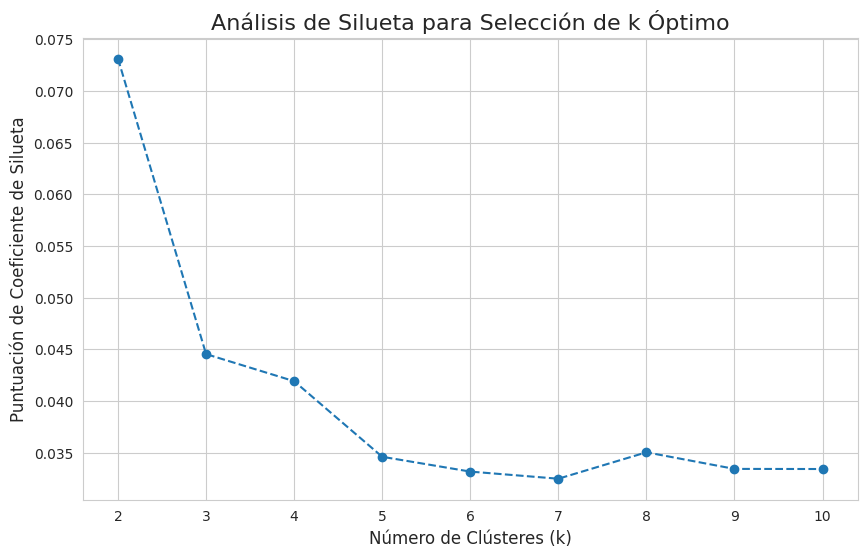


El análisis sugiere que el número óptimo de clústeres es k = 2.


In [8]:
#### **Fase 3 - Visualización y Decisión sobre k**

# --- 5.2. VISUALIZACIÓN Y DECISIÓN ---

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Análisis de Silueta para Selección de k Óptimo', fontsize=16)
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('Puntuación de Coeficiente de Silueta', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Determinar el k óptimo
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nEl análisis sugiere que el número óptimo de clústeres es k = {optimal_k}.")

**Magnitud de la Puntuación:** Una puntuación de silueta de 0.073 es **objetivamente baja** (la escala va hasta 1). Esto indica que, aunque `k=2` es la mejor estructura que el algoritmo pudo encontrar, los dos clústeres resultantes no están bien definidos. Tienen una separación débil y es probable que haya un solapamiento considerable entre ellos.

**Implicación de Negocio:** Un resultado de `k=2` a menudo sugiere que la división más fuerte y natural en los datos es binaria. Podría estar separando, por ejemplo, "empleados junior" vs. "empleados senior", o una división similar muy marcada. Sin embargo, la baja puntuación nos advierte que no debemos sobreinterpretar esta división como perfecta.

Para k = 2, la puntuación de silueta promedio es: 0.0731
Para k = 3, la puntuación de silueta promedio es: 0.0445
Para k = 4, la puntuación de silueta promedio es: 0.0419


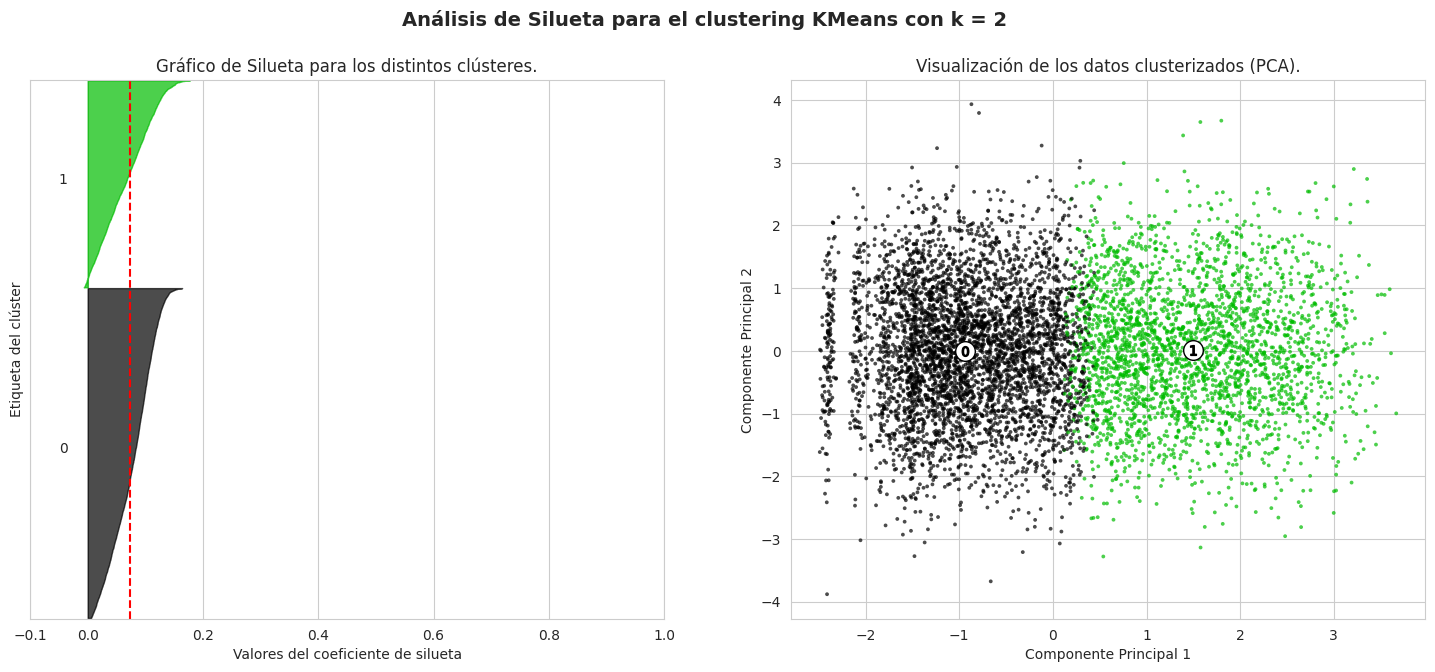

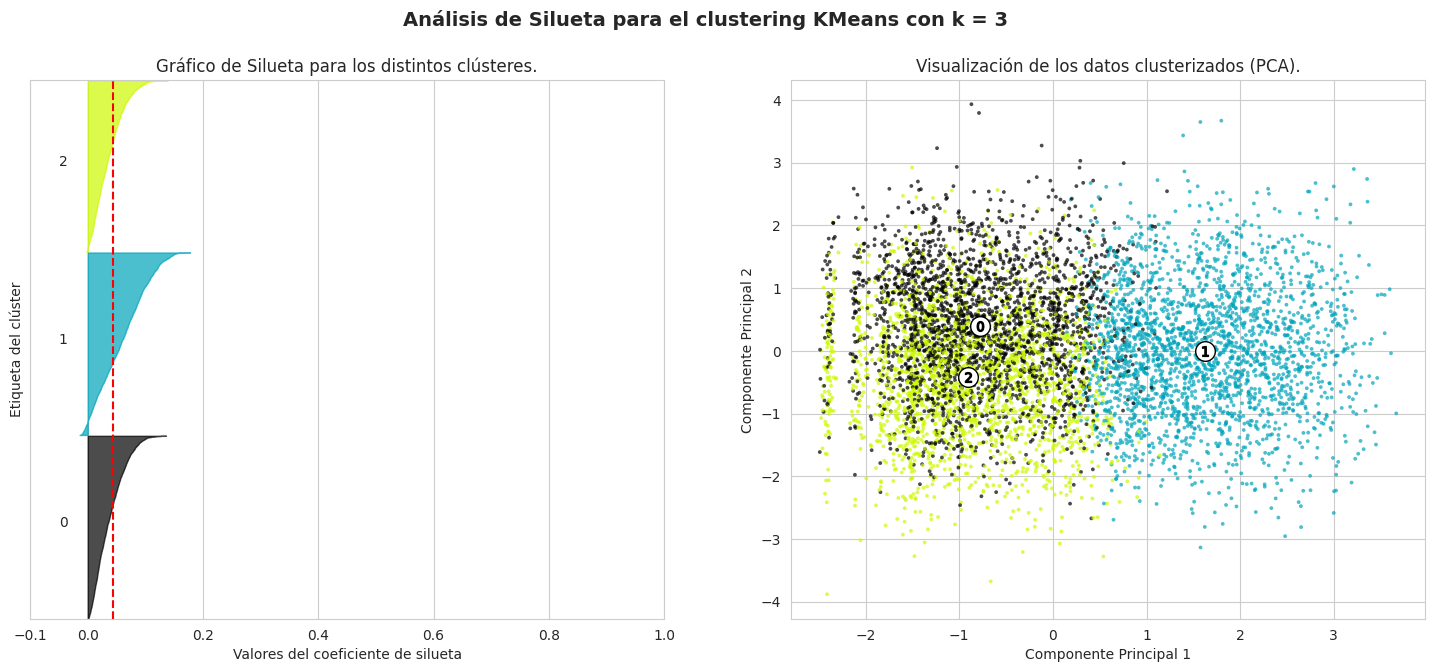

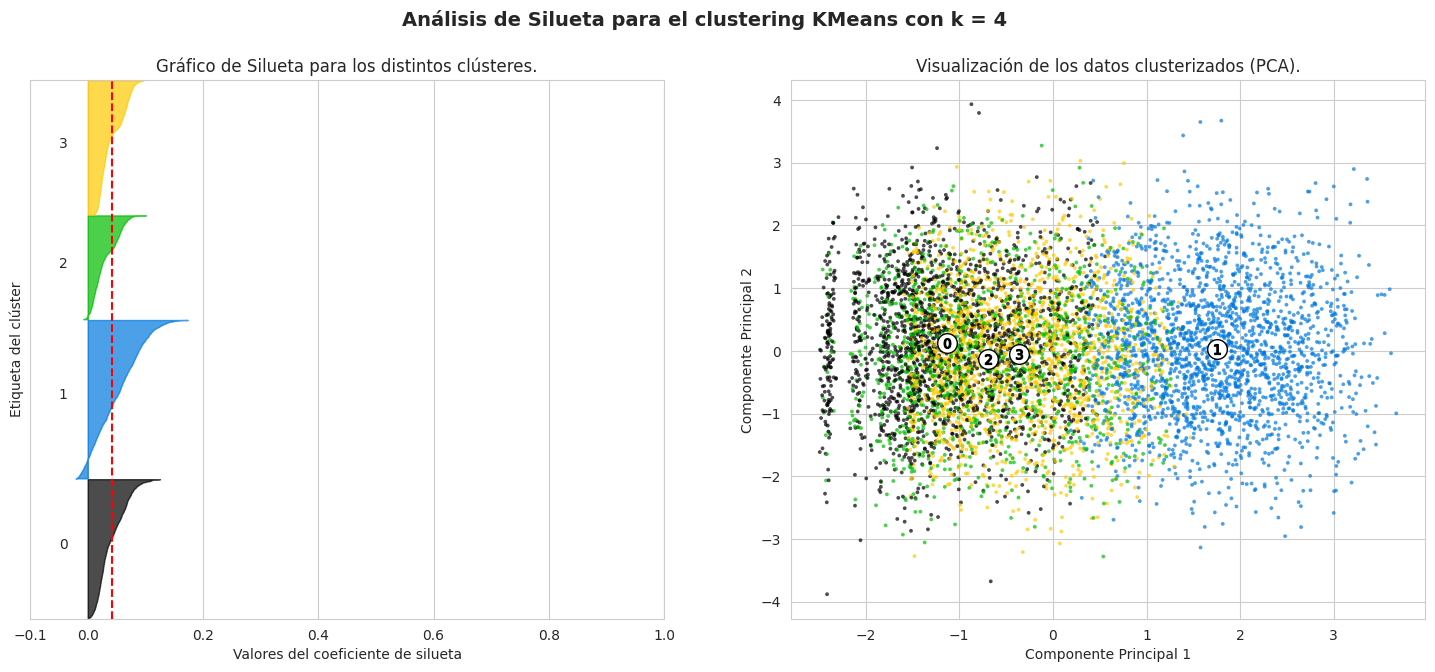

In [14]:
#### **Fase 3 - Diagnóstico con Gráficos de Silueta (Silhouette Plots)**

# --- 5.3. DIAGNÓSTICO DETALLADO CON SILHOUETTE PLOTS ---
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm # Para generar colores

# Vamos a generar gráficos para los k más interesantes:
# k=2 (el óptimo), k=3 y k=4 (para ver por qué no fueron elegidos)
k_to_plot = [2, 3, 4]

# Obtener los datos preprocesados una sola vez para eficiencia
X_processed = preprocessor.fit_transform(X)

for k in k_to_plot:
    # Crear una figura con 1 fila y 2 columnas
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # El primer subplot es el gráfico de silueta
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_processed) + (k + 1) * 10])

    # Entrenar el modelo KMeans para el k actual
    clusterer = KMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
    cluster_labels = clusterer.fit_predict(X_processed)

    # Calcular la puntuación de silueta promedio
    silhouette_avg = silhouette_score(X_processed, cluster_labels)
    print(f"Para k = {k}, la puntuación de silueta promedio es: {silhouette_avg:.4f}")

    # Calcular los valores de silueta para cada muestra
    sample_silhouette_values = silhouette_samples(X_processed, cluster_labels)

    y_lower = 10
    for i in range(k):
        # Agregar los valores de silueta para las muestras del clúster i y ordenarlos
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Etiquetar los gráficos de silueta con sus números de clúster en el medio
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 para el espacio en blanco entre gráficos

    ax1.set_title("Gráfico de Silueta para los distintos clústeres.")
    ax1.set_xlabel("Valores del coeficiente de silueta")
    ax1.set_ylabel("Etiqueta del clúster")

    # La línea vertical para la puntuación de silueta promedio de todos los valores
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Limpiar las etiquetas del eje y
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # El segundo subplot muestra los clústeres reales (usando PCA para reducir a 2D)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_processed)

    colors = cm.nipy_spectral(cluster_labels.astype(float) / k)
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Etiquetar los clústeres
    centers = clusterer.cluster_centers_
    centers_pca = pca.transform(centers)
    ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers_pca):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

    ax2.set_title("Visualización de los datos clusterizados (PCA).")
    ax2.set_xlabel("Componente Principal 1")
    ax2.set_ylabel("Componente Principal 2")

    plt.suptitle((f"Análisis de Silueta para el clustering KMeans con k = {k}"),
                 fontsize=14, fontweight='bold')

plt.show()

*   **Para k=2 (el óptimo):**
    *  El gráfico de silueta para k=2 confirma su estatus de óptimo. Ambos clústeres son de tamaño comparable y la mayoría de sus miembros están razonablemente bien asignados, como lo demuestra el hecho de que sus puntuaciones individuales superan el promedio global. Esto indica una estructura binaria estable, aunque no perfectamente separada.

*   **Para k=3 y k=4 (los sub-óptimos):**
    *  Al analizar los gráficos para k=3 y k=4, la degradación de la calidad del clustering es evidente. Estos modelos tienden a crear clústeres desbalanceados y con puntuaciones de silueta por debajo del promedio. La presencia de puntos con coeficientes negativos en estos casos sugiere que forzar más de dos segmentos introduce ambigüedad y asignaciones erróneas, validando así la elección de k=2 como la estructura más natural y defendible en los datos.

#### **Fase 4 - Modelado Final y Segmentación**


### 6. Modelado Final y Segmentación de Datos
Basado en el análisis cuantitativo previo, se ha seleccionado `k = [2]`. Ahora, se entrenará el modelo final con este hiperparámetro para asignar a cada empleado a su arquetipo correspondiente.

In [10]:
#### **Fase 4 - Ejecución del Entrenamiento Final**

# --- 6.1. ENTRENAMIENTO DEL MODELO FINAL ---

# Reconstruir el pipeline final con el k óptimo
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=optimal_k, n_init='auto', random_state=RANDOM_STATE))
])

# Entrenar el modelo final
print(f"Entrenando modelo final con k={optimal_k}...")
final_pipeline.fit(X)
print("Entrenamiento completado.")

# 6.2. Asignar etiquetas de clúster al DataFrame original
cluster_labels = final_pipeline.named_steps['clusterer'].labels_
df_original_interpretacion['cluster'] = cluster_labels

print(f"\nSe han asignado {len(np.unique(cluster_labels))} clústeres a los datos.")
display(df_original_interpretacion.head())

Entrenando modelo final con k=2...
Entrenamiento completado.

Se han asignado 2 clústeres a los datos.


,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,...,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate,cluster
0,EID_23371,F,42.00,4,Married,Franklin,IT,Conceptual,4.00,4,...,3.00,4,0.75,1.87,2.00,4,5,3,0.18,0
1,EID_18000,M,24.00,3,Single,Springfield,Logistics,Analytical,5.00,4,...,4.00,3,-0.96,-0.45,2.00,3,5,3,0.07,0
2,EID_3891,F,58.00,3,Married,Clinton,Quality,Conceptual,27.00,3,...,1.00,4,-0.96,-0.45,3.00,3,8,3,0.09,1
3,EID_17492,F,26.00,3,Single,Lebanon,Human Resource Management,Behavioral,4.00,3,...,1.00,3,-1.82,-0.45,NaN,3,7,3,0.07,0
4,EID_22534,F,31.00,1,Married,Springfield,Logistics,Conceptual,5.00,4,...,3.00,1,0.75,-0.45,2.00,2,8,2,0.18,0


#### **Fase 5 - Perfilado e Interpretación de Clústeres**


### 7. Perfilado de Clústeres y "Storytelling" con Datos
Esta es la fase de síntesis, donde traducimos los clústeres matemáticos en perfiles de negocio interpretables. Analizaremos las características promedio de cada grupo para construir una narrativa que explique quiénes son y qué los diferencia.


In [11]:
#### **Fase 5 - Tabla de Perfiles**

# --- 7.1. TABLA DE PERFILES ---

# Agrupar por clúster y calcular la media para numéricos y la moda para categóricos.
# La moda puede devolver múltiples valores si hay empates, por lo que tomamos el primero.
profile = df_original_interpretacion.groupby('cluster').agg({
    **{col: 'mean' for col in numeric_features},
    **{col: lambda x: x.mode()[0] for col in categorical_features}
})

# Añadir el tamaño de cada clúster y la tasa de deserción promedio
profile['count'] = df_original_interpretacion.groupby('cluster').size()
profile['Attrition_rate_mean'] = df_original_interpretacion.groupby('cluster')['Attrition_rate'].mean()

print("Tabla de Perfiles de Clústeres:")
# Transponer para mejor legibilidad
display(profile.T)

Tabla de Perfiles de Clústeres:


cluster,0,1
Age,30.24,54.14
Education_Level,3.20,3.16
Time_of_service,6.41,24.45
Time_since_promotion,2.26,2.53
growth_rate,47.20,46.85
Travel_Rate,0.82,0.82
Post_Level,2.80,2.80
Pay_Scale,5.97,6.06
Work_Life_balance,2.39,2.39
VAR1,3.08,3.12


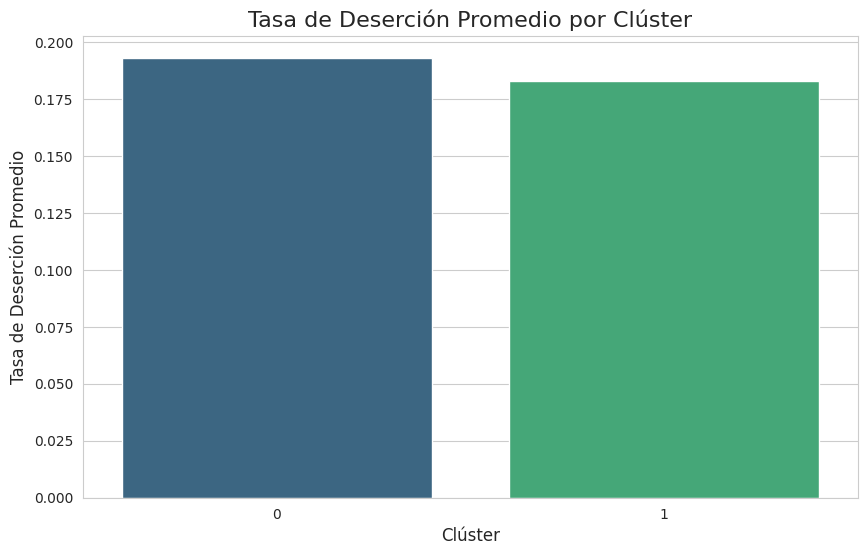

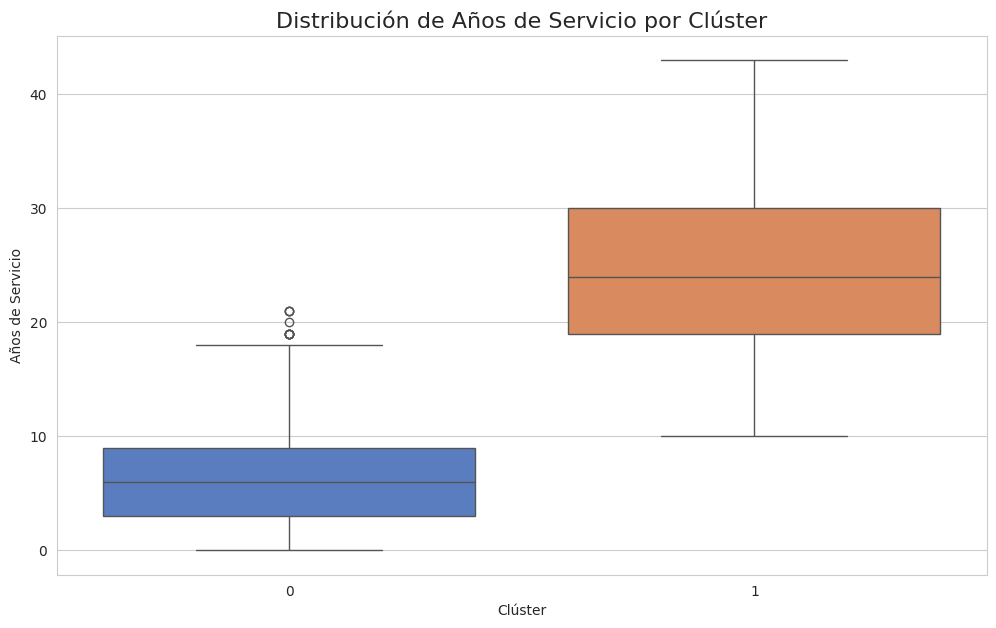

In [12]:
#### **Fase 5 - Visualización de Perfiles**

# --- 7.2. VISUALIZACIÓN DE PERFILES ---

# Gráfico de Tasa de Deserción por Clúster (El gráfico más importante)
plt.figure(figsize=(10, 6))
sns.barplot(x=profile.index, y=profile['Attrition_rate_mean'], palette='viridis')
plt.title('Tasa de Deserción Promedio por Clúster', fontsize=16)
plt.xlabel('Clúster', fontsize=12)
plt.ylabel('Tasa de Deserción Promedio', fontsize=12)
plt.show()

# Visualización de otras características clave
# Ejemplo: Edad vs. Ingresos por Clúster
fig = px.scatter(df_original_interpretacion,
                 x='Age',
                 y='growth_rate',
                 color='cluster',
                 title='Distribución de Clústeres por Edad y Tasa de Crecimiento',
                 hover_data=['Unit', 'Post_Level'])
fig.show()

# Ejemplo: Boxplot de Años en la Compañía
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_original_interpretacion, x='cluster', y='Time_of_service', palette='muted')
plt.title('Distribución de Años de Servicio por Clúster', fontsize=16)
plt.xlabel('Clúster')
plt.ylabel('Años de Servicio')
plt.show()

#### **Fase 5 - Conclusión y Narrativa**

### 8. Conclusión Accionable y Narrativa de los Segmentos


El análisis de clustering, guiado por una selección cuantitativa del número de clústeres mediante el Coeficiente de Silueta, determinó que la estructura más defendible en los datos corresponde a dos segmentos principales (k=2). Sin embargo, la evaluación posterior de estos grupos frente a la variable de negocio clave —la tasa de deserción— revela una homogeneidad inesperada. El Clúster 0 presenta una tasa de deserción promedio de 19.2%, mientras que el Clúster 1 registra una tasa de 18.3%. Ambas cifras se desvían de manera insignificante del promedio general de la compañía, que se sitúa en 19%. Esta mínima diferencia indica que la segmentación generada, aunque matemáticamente óptima según la estructura interna de los datos, no logra aislar un arquetipo de empleado con un riesgo de deserción distintivo.

Este resultado es consistente con la baja puntuación de silueta obtenida (~0.073), la cual advertía de una débil separación entre los clústeres. En términos prácticos, esto significa que las características disponibles en el dataset (demográficas, de rol y variables abstractas) no son predictores suficientemente potentes para diferenciar perfiles de riesgo de deserción. El algoritmo ha encontrado patrones, pero estos patrones no se correlacionan de forma significativa con el comportamiento de abandono. Para desarrollar una estrategia de retención de talento verdaderamente segmentada y accionable, sería necesario enriquecer el análisis con datos de mayor dimensionalidad cualitativa, como métricas de rendimiento, resultados de encuestas de satisfacción, o historial de interacciones con la gerencia.